# Simple Linear Regression with a Dirty Dataset

This notebook demonstrates:
- Creating a dirty dataset
- Cleaning the data
- Training a simple linear regression model
- Evaluating and visualizing results

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 2. Create a Dirty Dataset

In [2]:
# Create dirty data with various issues
data = {
    'hours': [1, 2, 3, 4, 5, 6, 7, 8, 'nine', 10, None, 12, 100],
    'score': [10, 20, 30, 40, 50, 60, None, 80, 90, 'hundred', 55, 120, 500]
}

df = pd.DataFrame(data)
print('Original Dirty Dataset:')
print(df)

Original Dirty Dataset:
   hours    score
0      1       10
1      2       20
2      3       30
3      4       40
4      5       50
5      6       60
6      7     None
7      8       80
8   nine       90
9     10  hundred
10  None       55
11    12      120
12   100      500


## 3. Data Cleaning

In [3]:
# Convert to numeric (invalid parsing will become NaN)
df['hours'] = pd.to_numeric(df['hours'], errors='coerce')
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# Drop missing values
df = df.dropna()

# Remove outliers (hours < 50 and score < 200)
df = df[(df['hours'] < 50) & (df['score'] < 200)]

print('Cleaned Dataset:')
print(df)

Cleaned Dataset:
    hours  score
0     1.0   10.0
1     2.0   20.0
2     3.0   30.0
3     4.0   40.0
4     5.0   50.0
5     6.0   60.0
7     8.0   80.0
11   12.0  120.0


## 4. Prepare Data for Training

In [4]:
# Prepare features and target
X = df[['hours']]
y = df['score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {len(X_train)}')
print(f'Testing set size: {len(X_test)}')

Training set size: 6
Testing set size: 2


## 5. Train the Linear Regression Model

In [5]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


## 6. Make Predictions and Evaluate

In [6]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))

MSE: 3.155443620884047e-29
R2 Score: 1.0


## 7. Visualization

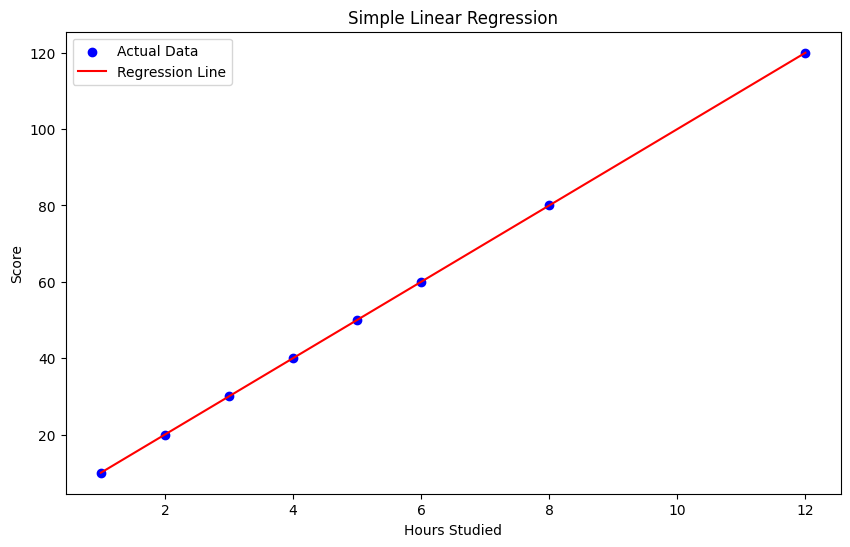

In [7]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

## 8. Model Parameters and Prediction

In [8]:
# Display model parameters
print('Slope:', model.coef_[0])
print('Intercept:', model.intercept_)

# Example prediction for 9 hours of study
new_hours = np.array([[9]])
predicted_score = model.predict(new_hours)[0]
print(f'Predicted score for 9 hours: {predicted_score:.2f}')

Slope: 9.999999999999998
Intercept: 7.105427357601002e-15
Predicted score for 9 hours: 90.00


/home/sanjaya7/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
